In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset directory
DATASET_DIR = Path("/Users/nedamohseni/Downloads/SoLo_dataset")

In [2]:
ema_dfs = []

for participant_dir in sorted(DATASET_DIR.iterdir()):
    if not participant_dir.is_dir():
        continue

    ema_path = participant_dir / "Self_Report" / "ema_daily.csv"

    if ema_path.exists():
        df = pd.read_csv(ema_path)
        df["participant"] = participant_dir.name
        ema_dfs.append(df)

ema_df = pd.concat(ema_dfs, ignore_index=True)
ema_df

,participant,date,timestamp,surveyindex,PANAS_active,PANAS_afraid,PANAS_ashamed,PANAS_attentive,PANAS_determined,PANAS_distressed,...,feel_connected,feel_isolated,feel_lonely,number_social_interactions,pleasant_social_interactions,who_interaction,sleep_time,wake_time,rested_score,quality_score
0,pers2001,2022-01-24,1643053391977,0,100.0,0.0,0.0,52.0,75.0,0.0,...,32.0,32.0,33.0,1.0,52.0,{'strangers': True},1.643019e+12,1.643052e+12,98.0,80.0
1,pers2001,2022-01-24,1643073066086,2,NaN,NaN,NaN,NaN,NaN,NaN,...,100.0,0.0,0.0,10.0,100.0,{'classmates': True},NaN,NaN,NaN,NaN
2,pers2001,2022-01-24,1643091313274,4,97.0,0.0,0.0,59.0,95.0,36.0,...,19.0,60.0,70.0,2.0,42.0,{'friends': True},NaN,NaN,NaN,NaN
3,pers2001,2022-01-25,1643133350138,0,0.0,0.0,0.0,50.0,50.0,0.0,...,0.0,0.0,0.0,0.0,NaN,{'na': True},1.643143e+12,1.643130e+12,80.0,70.0
4,pers2001,2022-01-25,1643159024078,2,NaN,NaN,NaN,NaN,NaN,NaN,...,100.0,0.0,0.0,10.0,70.0,"{'acquaintances': True, 'classmates': True, 'f...",NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11228,pers2038,2022-06-25,1656210023078,2,NaN,NaN,NaN,NaN,NaN,NaN,...,84.0,13.0,16.0,1.0,90.0,{'partners': True},NaN,NaN,NaN,NaN
11229,pers2038,2022-06-26,1656269110866,0,9.0,13.0,16.0,6.0,42.0,12.0,...,83.0,10.0,19.0,1.0,83.0,{'partners': True},1.656244e+12,1.656269e+12,26.0,17.0
11230,pers2038,2022-06-27,1656377312252,2,NaN,NaN,NaN,NaN,NaN,NaN,...,89.0,15.0,5.0,1.0,88.0,{'partners': True},NaN,NaN,NaN,NaN
11231,pers2038,2022-06-28,1656402021084,4,12.0,13.0,11.0,10.0,13.0,16.0,...,98.0,9.0,9.0,1.0,91.0,{'partners': True},NaN,NaN,NaN,NaN


In [3]:
LABELS = ["feel_lonely", "feel_isolated", "feel_connected"]

participant_counts = ema_df.groupby("participant").size()

print(f"Total EMA entries: {len(ema_df):,}")
print(f"Participants: {ema_df['participant'].nunique()}")
print(f"EMA entries per participant: mean = {participant_counts.mean():.2f}, "
      f"SD = {participant_counts.std():.2f}")

Total EMA entries: 11,233
Participants: 31
EMA entries per participant: mean = 362.35, SD = 157.29


In [6]:
has_target_label = ema_df[LABELS].notna().any(axis=1)

print(f"EMA entries with at least one target label: {has_target_label.sum():,}")
print(f"Percentage of EMA entries with at least one target label: "
      f"{has_target_label.mean() * 100:.1f}%")

print("\nTarget label summary:")
for label in LABELS:
    print(f"{label}: n = {ema_df[label].count():,}, "
          f"mean = {ema_df[label].mean():.2f}, "
          f"SD = {ema_df[label].std():.2f}")

EMA entries with at least one target label: 10,647
Percentage of EMA entries with at least one target label: 94.8%

Target label summary:
feel_lonely: n = 10,616, mean = 19.34, SD = 20.58
feel_isolated: n = 10,521, mean = 19.94, SD = 21.50
feel_connected: n = 10,052, mean = 56.53, SD = 29.38


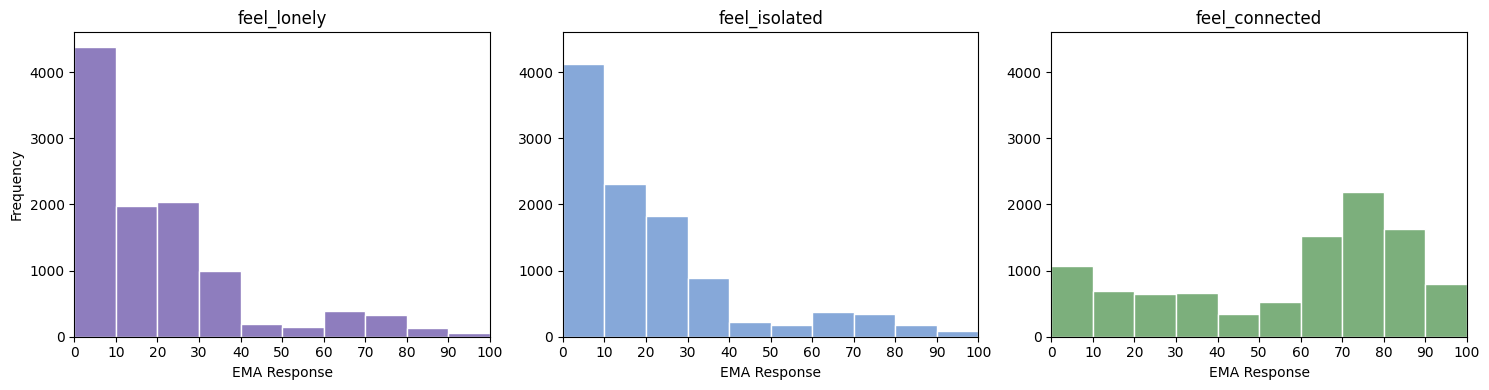

In [36]:
colors = ["#8E7DBE", "#86A8D9", "#7CAF7C"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
bins = np.arange(0, 110, 10)

for ax, label, color in zip(axes, LABELS, colors):
    ax.hist(ema_df[label].dropna(), bins=bins, color=color,
            edgecolor="white", linewidth=1)

    ax.set_title(label)
    ax.set_xlabel("EMA Response")
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 10))
    ax.tick_params(axis="y", labelleft=True)

axes[0].set_ylabel("Frequency")

plt.tight_layout()
plt.show()